<a href="https://colab.research.google.com/github/SalmaAnindhia/PemMes_25_Salma/blob/main/JS06/JS06_01_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

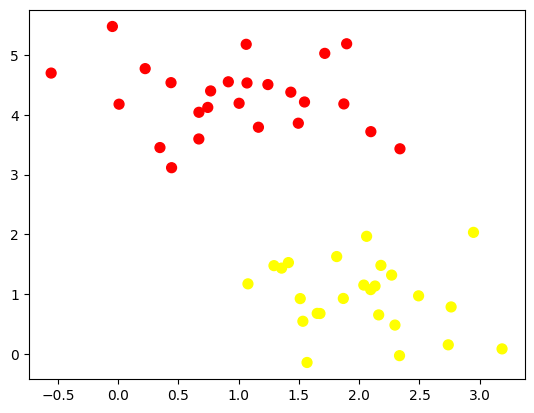

In [2]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=50, centers=2,
                  random_state=0, cluster_std=0.60)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')

(-1.0, 3.5)

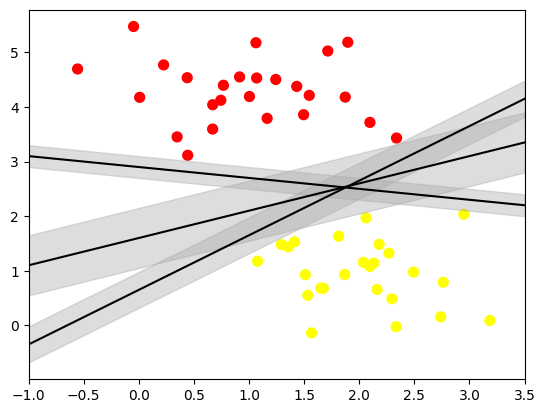

In [3]:
xfit = np.linspace(-1, 3.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')

for m, b, d in [(1, 0.65, 0.33), (0.5, 1.6, 0.55), (-0.2, 2.9, 0.2)]:
    yfit = m * xfit + b
    plt.plot(xfit, yfit, '-k')
    plt.fill_between(xfit, yfit - d, yfit + d, edgecolor='none',
                     color='#AAAAAA', alpha=0.4)

plt.xlim(-1, 3.5)

In [4]:
from sklearn.svm import SVC # "Support vector classifier"
model = SVC(kernel='linear', C=1E10)
model.fit(X, y)

SVC(C=10000000000.0, kernel='linear')

In [5]:
def plot_svc_decision_function(model, ax=None, plot_support=True):

    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

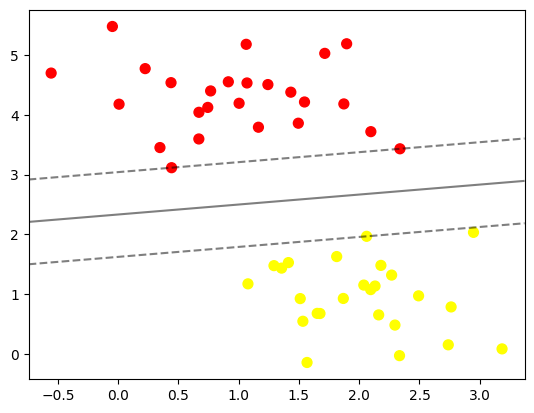

In [6]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(model)

In [7]:
model.support_vectors_

array([[0.44359863, 3.11530945],
       [2.33812285, 3.43116792],
       [2.06156753, 1.96918596]])

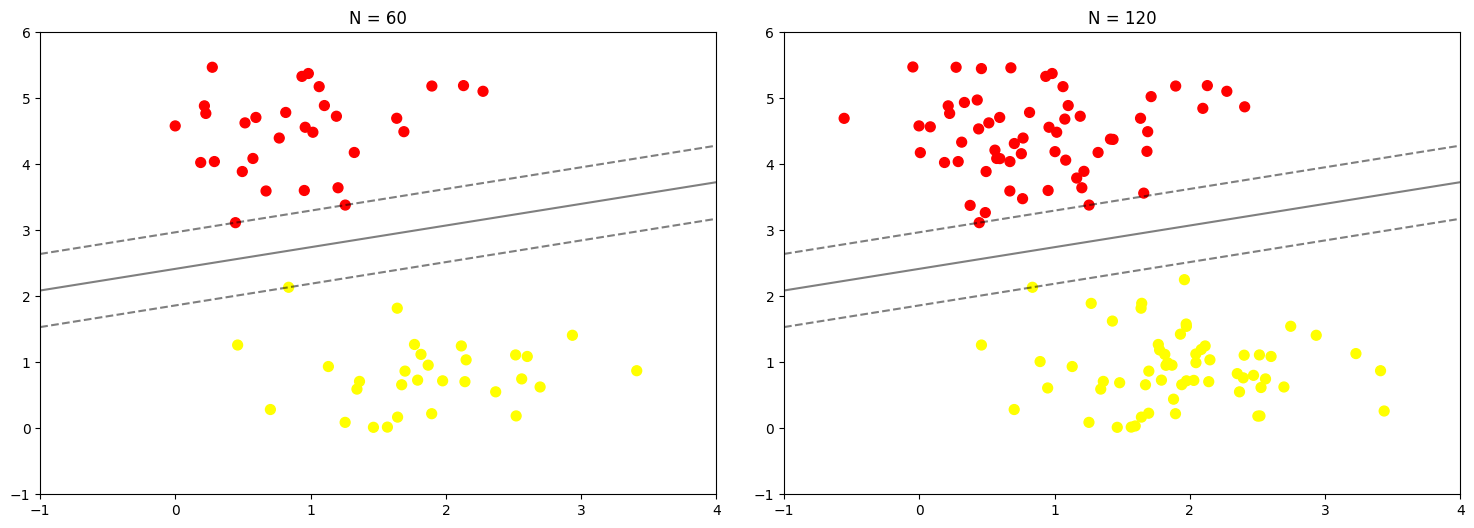

In [8]:
def plot_svm(N=10, ax=None):
    X, y = make_blobs(n_samples=200, centers=2,
                      random_state=0, cluster_std=0.60)
    X = X[:N]
    y = y[:N]
    model = SVC(kernel='linear', C=1E10)
    model.fit(X, y)

    ax = ax or plt.gca()
    ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
    ax.set_xlim(-1, 4)
    ax.set_ylim(-1, 6)
    plot_svc_decision_function(model, ax)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)
for axi, N in zip(ax, [60, 120]):
    plot_svm(N, axi)
    axi.set_title('N = {0}'.format(N))

In [10]:
!pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 29.3 MB/s eta 0:00:00


In [11]:
from ipywidgets import interact, fixed
interact(plot_svm, N=[10, 200], ax=fixed(None))

interactive(children=(Dropdown(description='N', options=(10, 200), value=10), Output()), _dom_classes=('widget…

<function __main__.plot_svm(N=10, ax=None)>

In [12]:
from sklearn.svm import SVC

In [13]:
def plot_svc_decision_function(model, ax=None, plot_support=True):

    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

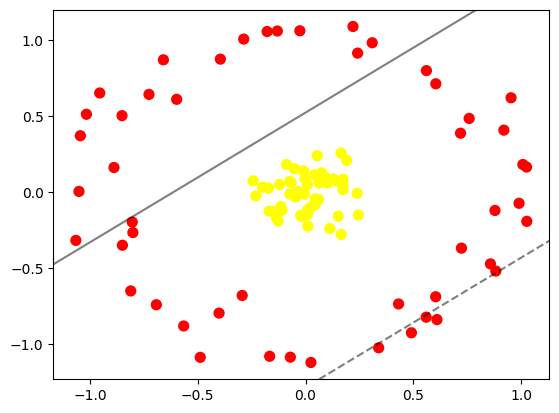

In [14]:
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

clf = SVC(kernel='linear').fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf, plot_support=False);

In [15]:
r = np.exp(-(X**2).sum(1))

In [17]:
from mpl_toolkits import mplot3d
from ipywidgets import interact, fixed

def plot_3D(elev=30, azim=30, X=X, y=y):
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap='autumn')
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('r')

interact(plot_3D, elev=[-90, 45, 30, 20 , 10], azim=(-180, 180),
         X=fixed(X), y=fixed(y))

interactive(children=(Dropdown(description='elev', index=2, options=(-90, 45, 30, 20, 10), value=30), IntSlide…

<function __main__.plot_3D(elev=30, azim=30, X=array([[-1.06530289, -0.31942745],
       [-0.07255906,  0.06902949],
       [ 0.24579117, -0.15198705],
       [ 0.30948247,  0.98065734],
       [-0.10928517, -0.12078871],
       [-0.59781568,  0.60855209],
       [-0.0019932 ,  0.08617779],
       [-0.01469908, -0.16311787],
       [-0.07238496, -0.01462692],
       [ 0.4316349 , -0.73753707],
       [ 0.02522816, -1.12250811],
       [ 0.99063827, -0.07545984],
       [ 0.17387867,  0.01384208],
       [-0.29386114, -0.68170594],
       [-0.13460907, -0.17125342],
       [-0.12058319,  0.04843462],
       [ 0.9535182 ,  0.61859953],
       [ 0.85801754, -0.47383831],
       [ 0.11256336, -0.24177339],
       [ 0.87905102, -0.12233242],
       [-0.04475405, -0.03011527],
       [ 0.16503464,  0.25576663],
       [ 0.17399394,  0.08317071],
       [ 0.75921944,  0.48291236],
       [-0.85136733,  0.50106586],
       [-0.24316538,  0.07262811],
       [ 0.06075565, -0.05062835],
       [ 0.05440479,  0.23813773],
       [-0.00907408,  0.13802969],
       [-0.23047305, -0.02715302],
       [ 0.12790758,  0.08596904],
       [-0.1989304 ,  0.03041491],
       [-1.0509973 ,  0.00255447],
       [-1.0446291 ,  0.36910104],
       [ 0.00851327, -0.15073876],
       [ 0.08898694,  0.10063541],
       [ 1.02543602,  0.16313463],
       [-1.01649482,  0.51026663],
       [ 0.71928095,  0.38577659],
       [ 0.04400737, -0.08533332],
       [-0.00464886, -0.01599643],
       [ 0.24166362,  0.91258532],
       [-0.95472379,  0.65017753],
       [-0.1717452 ,  0.02435579],
       [ 1.0083735 ,  0.17992863],
       [ 0.49136761, -0.92721551],
       [-0.0262196 ,  1.05944055],
       [-0.6921157 , -0.74267525],
       [-0.17810782,  1.05434673],
       [-0.16635002, -1.08171501],
       [-0.1145627 , -0.09619418],
       [-0.13072891,  1.05784815],
       [ 0.22025932,  1.08774673],
       [ 0.56101594,  0.79733189],
       [-0.12719491, -0.19246792],
       [-0.28671862,  1.00492793],
       [ 0.23952449, -0.00996144],
       [-0.80400321, -0.19879513],
       [ 0.19107641,  0.207151  ],
       [-0.88864695,  0.16018392],
       [-0.02254923, -0.15402463],
       [ 0.14573622,  0.07035625],
       [-0.08758693,  0.17949069],
       [-0.04730281, -0.03381339],
       [ 0.15205628, -0.16066054],
       [-0.72619658,  0.64089534],
       [-0.07035201, -1.08752826],
       [ 0.062938  ,  0.05826101],
       [-0.39512133,  0.87287978],
       [ 0.0092428 ,  0.04830756],
       [ 0.88288977, -0.52118089],
       [ 0.01000666, -0.11897373],
       [-0.56523101, -0.88234275],
       [ 0.92033097,  0.40596243],
       [ 0.72337907, -0.37035673],
       [ 0.10300054,  0.05874879],
       [ 0.02183773, -0.10478719],
       [ 0.0453234 , -0.04640527],
       [ 0.01119464, -0.22599825],
       [ 0.07372237,  0.12443821],
       [-0.04994119,  0.15177769],
       [-0.03460964,  0.00215073],
       [-0.1550441 , -0.1286267 ],
       [-0.80086723, -0.26757257],
       [ 0.60391417, -0.69025344],
       [ 0.60453914,  0.71071013],
       [ 0.16553572, -0.28094066],
       [ 0.33943696, -1.02591318],
       [-0.488429  , -1.08875915],
       [-0.84947464, -0.35129323],
       [-0.16861474, -0.12652079],
       [-0.40110746, -0.79775479],
       [ 0.04311887,  0.11210957],
       [ 0.6099049 , -0.84029719],
       [-0.81084355, -0.65189728],
       [-0.65938549,  0.8683865 ],
       [ 0.55972399, -0.82458488],
       [-0.06658046,  0.06050229],
       [ 0.17448036,  0.0389737 ],
       [ 1.02663591, -0.19393588]]), y=array([0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0]))>

In [18]:
clf = SVC(kernel='rbf', C=1E6)
clf.fit(X, y)

SVC(C=1000000.0)

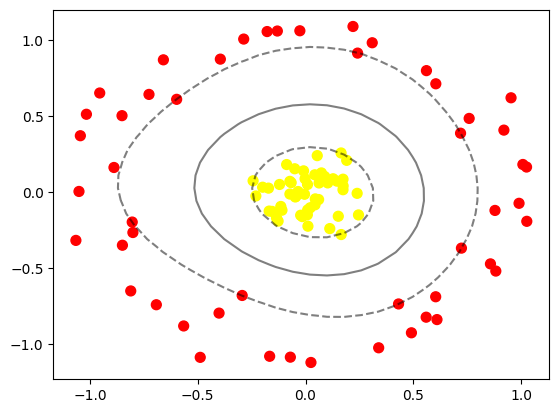

In [19]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=300, lw=1, facecolors='none')